<a href="https://colab.research.google.com/github/oerv13-gh/Ibero/blob/main/Vision_Pc_Act2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preprocesar la imagen 'foto_exito.png' aplicando filtros de ruido (Gaussiano, Mediana y Promedio), normalización de intensidades, corrección de color y balance de blancos, y transformaciones geométricas (escalado, rotación, traslación, perspectiva)

**Cargar y Mostrar Imagen Original**

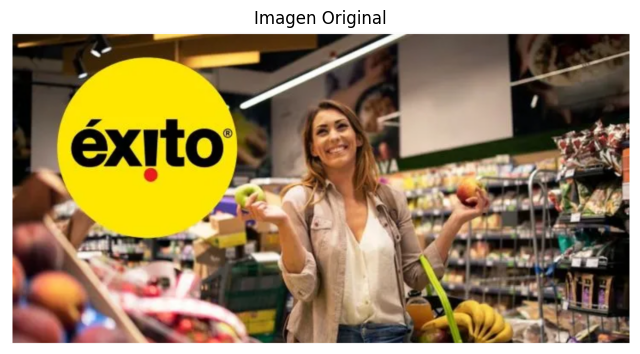

In [1]:
import cv2
import matplotlib.pyplot as plt

# Cargar la imagen
image_path = '/content/sample_data/foto_exito.png'
original_image_bgr = cv2.imread(image_path)

# Convertir la imagen de BGR a RGB (Matplotlib usa RGB)
original_image_rgb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2RGB)

# Mostrar la imagen original
plt.figure(figsize=(8, 6))
plt.imshow(original_image_rgb)
plt.title('Imagen Original')
plt.axis('off')
plt.show()

Aplicar Filtros de Ruido

Implementar y aplicar filtros de ruido (Gaussiano, Mediana y Promedio) a la imagen original, mostrando los resultados de cada uno para comparar su efecto.

Definiré una función auxiliar para mostrar varias imágenes en una cuadrícula, luego aplicaré filtros de desenfoque Gaussano, Mediano y Medio a la imagen original usando OpenCV, y finalmente mostraré todas las imágenes procesadas junto a la original para comparar

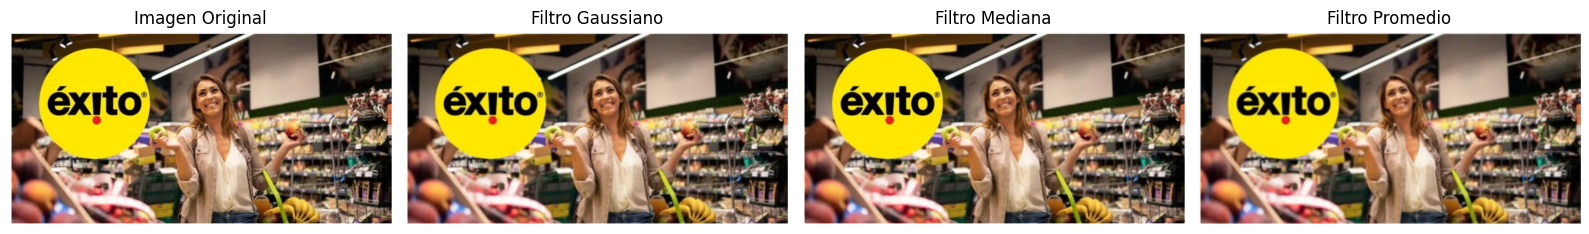

In [2]:
def show_images(images_dict):
    """
    Displays images from a dictionary in a grid.
    keys: titles, values: images
    """
    num_images = len(images_dict)
    plt.figure(figsize=(num_images * 4, 6))
    for i, (title, img) in enumerate(images_dict.items()):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 2. Aplicar filtro Gaussiano
# Kernel size (5,5), sigmaX=0 (calculado automáticamente)
gaussian_filtered_image = cv2.GaussianBlur(original_image_rgb, (5, 5), 0)

# 3. Aplicar filtro de Mediana
# Kernel size 5 (debe ser impar)
median_filtered_image = cv2.medianBlur(original_image_rgb, 5)

# 4. Aplicar filtro Promedio (Box blur)
# Kernel size (5,5)
average_filtered_image = cv2.blur(original_image_rgb, (5, 5))

# 5. Mostrar todas las imágenes comparativamente
images_to_show = {
    'Imagen Original': original_image_rgb,
    'Filtro Gaussiano': gaussian_filtered_image,
    'Filtro Mediana': median_filtered_image,
    'Filtro Promedio': average_filtered_image
}

show_images(images_to_show)

Normalización de Intensidades

Aplicar técnicas de normalización de intensidades o contraste a la imagen, y visualizar el resultado para observar la mejora en el rango dinámico.

Convertir la imagen RGB a escala de grises para la ecualización del histograma, aplicar la ecualización y luego la convertir de nuevo a RGB. Para la normalización min-max, normalizar directamente la imagen RGB. Por último, mostrar todas las imágenes procesadas junto con el original para comparar usando la función auxiliar.

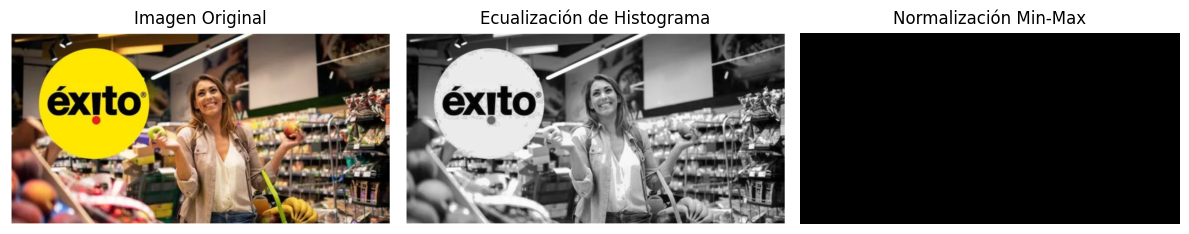

In [3]:
import numpy as np

# 1. Convert original_image_rgb to grayscale for histogram equalization
grayscale_image = cv2.cvtColor(original_image_rgb, cv2.COLOR_RGB2GRAY)

# 2. Apply histogram equalization to the grayscale image
equalized_grayscale = cv2.equalizeHist(grayscale_image)

# 3. Convert the equalized_grayscale image back to a 3-channel RGB image for consistent display
equalized_image = cv2.cvtColor(equalized_grayscale, cv2.COLOR_GRAY2RGB)

# 4. Apply min-max normalization to the original_image_rgb
# Convert to float first for precise normalization
original_image_float = original_image_rgb.astype(np.float32)
normalized_minmax_image = np.zeros(original_image_float.shape, dtype=np.float32)
cv2.normalize(original_image_float, normalized_minmax_image, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
normalized_minmax_image = normalized_minmax_image.astype(np.uint8)


# 5. Display the images
images_to_show_normalization = {
    'Imagen Original': original_image_rgb,
    'Ecualización de Histograma': equalized_image,
    'Normalización Min-Max': normalized_minmax_image
}

show_images(images_to_show_normalization)

Corrección de Color y Balance de Blancos

Realizar una corrección de color y balance de blancos para ajustar los tonos y colores de la imagen, y mostrar el resultado.

Para la corrección de gamma, uso un valor gamma de 1,2 para iluminar ligeramente la imagen, ya que esto suele ayudar a mejorar la visibilidad sin sobresaturación.

Para el balance de blancos usando el algoritmo Gray World, convertir la imagen para que flote y normalizar sus valores a [0, 1] para asegurar cálculos precisos. La idea central es asumir que el color medio de una escena es acromático (gris). Por lo tanto, calcular la intensidad media de cada canal de color (R, G, B) y luego determinar un promedio global. Los factores de escalado se derivarán dividiendo el promedio global entre el promedio de cada canal. Aplicar estos factores ajustará los canales de color para que la imagen parezca más neutra. Finalmente, la imagen se recortará a [0, 1] y se redimensionará a [0, 255] como uint8 para una visualización adecuada.

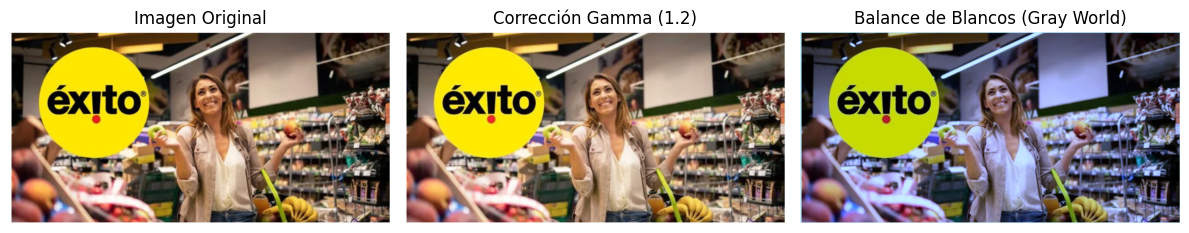

In [4]:
import numpy as np

# 1. Aplicar corrección gamma
def apply_gamma_correction(image, gamma=1.0):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

gamma_corrected_image = apply_gamma_correction(original_image_rgb, gamma=1.2)

# 2. Implementar balance de blancos utilizando el algoritmo Gray World
def apply_gray_world_white_balance(image):
    # a. Convertir la imagen a un tipo flotante y normalizar sus valores en el rango [0, 1]
    img_float = image.astype(np.float32) / 255.0

    # b. Calcular el valor promedio de intensidad para cada canal de color (R, G, B)
    avg_b = np.mean(img_float[:, :, 2])
    avg_g = np.mean(img_float[:, :, 1])
    avg_r = np.mean(img_float[:, :, 0])

    # c. Calcular el valor promedio global de intensidad entre los tres canales.
    avg_gray = (avg_r + avg_g + avg_b) / 3.0

    # d. Determinar los factores de escala para cada canal
    scale_r = avg_gray / avg_r
    scale_g = avg_gray / avg_g
    scale_b = avg_gray / avg_b

    # e. Aplicar estos factores de escala a cada canal de la imagen.
    balanced_img = np.zeros_like(img_float)
    balanced_img[:, :, 0] = img_float[:, :, 0] * scale_r
    balanced_img[:, :, 1] = img_float[:, :, 1] * scale_g
    balanced_img[:, :, 2] = img_float[:, :, 2] * scale_b

    # f. Recortar los valores resultantes al rango [0, 1] y luego escalarlos a [0, 255] y convertir a uint8.
    balanced_img = np.clip(balanced_img, 0, 1)
    balanced_img_uint8 = (balanced_img * 255).astype(np.uint8)

    return balanced_img_uint8

white_balanced_image = apply_gray_world_white_balance(original_image_rgb)

# 3. Mostrar las imágenes comparativamente
images_to_show_color_balance = {
    'Imagen Original': original_image_rgb,
    'Corrección Gamma (1.2)': gamma_corrected_image,
    'Balance de Blancos (Gray World)': white_balanced_image
}

show_images(images_to_show_color_balance)

Aplicar Transformaciones Geométricas

Implementar y aplicar transformaciones geométricas como escalado, rotación, traslación y perspectiva a la imagen, mostrando cada transformación de forma individual.

Implementar las transformaciones geométricas (escalado, rotación, traslación y perspectiva) usando funciones de OpenCV y mostrar todas las imágenes transformadas junto con la original usando la función de ayuda

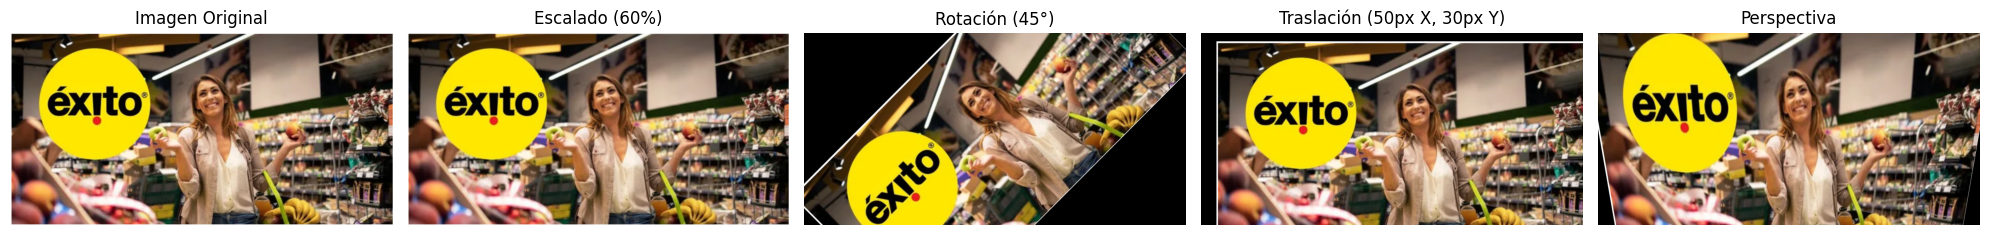

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ensure show_images function is available (re-defining for completeness in this block if not globally available, though it was in a previous cell)
def show_images(images_dict):
    """
    Displays images from a dictionary in a grid.
    keys: titles, values: images
    """
    num_images = len(images_dict)
    plt.figure(figsize=(num_images * 4, 6))
    for i, (title, img) in enumerate(images_dict.items()):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 1. Transformación de Escalado (Scaling)
scale_percent = 60 # percent of original size
width = int(original_image_rgb.shape[1] * scale_percent / 100)
height = int(original_image_rgb.shape[0] * scale_percent / 100)
dim = (width, height)
scaled_image = cv2.resize(original_image_rgb, dim, interpolation = cv2.INTER_AREA)

# 2. Transformación de Rotación (Rotation)
(h, w) = original_image_rgb.shape[:2]
center = (w // 2, h // 2)
angle = 45
scale = 1.0
M_rotate = cv2.getRotationMatrix2D(center, angle, scale)
rotated_image = cv2.warpAffine(original_image_rgb, M_rotate, (w, h))

# 3. Transformación de Traslación (Translation)
tx = 50 # move 50 pixels right
ty = 30 # move 30 pixels down
M_translate = np.float32([[1, 0, tx],
                          [0, 1, ty]])
translated_image = cv2.warpAffine(original_image_rgb, M_translate, (w, h))

# 4. Transformación de Perspectiva (Perspective)
# Define 4 source points (corners of the original image, or a region of interest)
pts1 = np.float32([[50, 50], [w-50, 50], [50, h-50], [w-50, h-50]])
# Define 4 destination points (how the corners will be transformed)
pts2 = np.float32([[0, 0], [w, 0], [100, h], [w-100, h]])

M_perspective = cv2.getPerspectiveTransform(pts1, pts2)
perspective_image = cv2.warpPerspective(original_image_rgb, M_perspective, (w, h))

# 5. Mostrar todas las imágenes comparativamente
images_to_show_geometric = {
    'Imagen Original': original_image_rgb,
    'Escalado (60%)': scaled_image,
    'Rotación (45°)': rotated_image,
    'Traslación (50px X, 30px Y)': translated_image,
    'Perspectiva': perspective_image
}

show_images(images_to_show_geometric)

Las técnicas de preprocesamiento aplicadas a 'foto_exito.png' afectan significativamente su calidad visual y su idoneidad para un modelo de visión por ordenador de la siguiente manera:

Reducción de ruido: Los filtros gaussiano, mediano y medio reducen eficazmente el ruido, siendo el filtro mediano especialmente fuerte contra el ruido de 'sal y pimienta', mientras conserva mejor los bordes que los otros dos. Esto ayuda a que los modelos se centren en las características en lugar del ruido.

Normalización de intensidad: La ecualización por histogramas mejora enormemente el contraste global, haciendo que los detalles sean más discernibles. La normalización Min-Max garantiza que los valores de píxeles estén dentro de un rango consistente (0-255), lo cual es crucial para un entrenamiento estable de redes neuronales.

Corrección de color y balance de blancos: La corrección gamma (con un valor de 1,2) ilumina las zonas oscuras, mejorando la visibilidad en las sombras. El algoritmo de Balance de Blancos del Mundo Gris corrige las tonalidades de color, lo que conduce a colores más naturales y precisos, lo cual es vital para modelos que dependen de información de color precisa.

Transformaciones geométricas: El escalado (hasta el 60% del original), la rotación (45 grados), la traslación (50 píxeles a la derecha, 30 píxeles abajo) y las transformaciones de perspectiva sirven como técnicas potentes de aumento de datos. Hacen que los modelos de visión por ordenador sean más robustos a variaciones en el tamaño, orientación, posición y ángulo de visión de los objetos, mejorando las capacidades de generalización.
